In [8]:
from opcua import Client

client = Client("opc.tcp://localhost:49320")
client.connect()
print("Tilkoblet!")

# Test én tag
node = client.get_node("ns=2;s=Rigg1.PLS1.slider")
print("slider verdi:", node.get_value())

client.disconnect()

Requested session timeout to be 3600000ms, got 60000ms instead


Tilkoblet!
slider verdi: 60


In [5]:
import asyncio
import csv
from datetime import datetime
from asyncua import Client
import nest_asyncio
nest_asyncio.apply()

filnavn = "plc_data_FO"

OPC_URL = "opc.tcp://localhost:49320"
CSV_FIL = f"{filnavn}.csv"
INTERVALL_SEK = 2

TAGS = {
    "pådrag":     "ns=2;s=Rigg1.PLS1.flow",
    "tank":       "ns=2;s=Rigg1.PLS1.tank",
}

async def main():
    async with Client(url=OPC_URL) as client:
        print(f"Koblet til {OPC_URL}")

        noder = {navn: client.get_node(adresse) for navn, adresse in TAGS.items()}

        with open(CSV_FIL, mode="w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow(["Tidsstempel"] + list(TAGS.keys()))

            for _ in range(10000):  # Endre til while True for evig kjøring
                tidsstempel = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
                verdier = []

                for navn, node in noder.items():
                    try:
                        verdi = await node.read_value()
                        verdier.append(verdi)
                    except Exception as e:
                        print(f"Feil ved lesing av '{navn}': {e}")
                        verdier.append(None)

                writer.writerow([tidsstempel] + verdier)
                f.flush()
                print(f"[{tidsstempel}] {dict(zip(TAGS.keys(), verdier))}")
                await asyncio.sleep(INTERVALL_SEK)

    print(f"Ferdig! Data lagret i '{CSV_FIL}'")

asyncio.run(main())

Requested session timeout to be 3600000ms, got 60000ms instead


Koblet til opc.tcp://localhost:49320
[2026-03-18 10:54:40] {'pådrag': 25, 'tank': 38}
[2026-03-18 10:54:42] {'pådrag': 25, 'tank': 37}
[2026-03-18 10:54:44] {'pådrag': 25, 'tank': 36}
[2026-03-18 10:54:46] {'pådrag': 25, 'tank': 35}
[2026-03-18 10:54:48] {'pådrag': 25, 'tank': 36}
[2026-03-18 10:54:50] {'pådrag': 25, 'tank': 36}
[2026-03-18 10:54:53] {'pådrag': 25, 'tank': 35}
[2026-03-18 10:54:55] {'pådrag': 25, 'tank': 34}
[2026-03-18 10:54:57] {'pådrag': 25, 'tank': 34}
[2026-03-18 10:54:59] {'pådrag': 25, 'tank': 33}
[2026-03-18 10:55:01] {'pådrag': 25, 'tank': 34}
[2026-03-18 10:55:03] {'pådrag': 25, 'tank': 35}
[2026-03-18 10:55:05] {'pådrag': 25, 'tank': 35}
[2026-03-18 10:55:07] {'pådrag': 25, 'tank': 34}
[2026-03-18 10:55:09] {'pådrag': 25, 'tank': 33}
[2026-03-18 10:55:11] {'pådrag': 25, 'tank': 32}
[2026-03-18 10:55:13] {'pådrag': 25, 'tank': 32}
[2026-03-18 10:55:15] {'pådrag': 25, 'tank': 32}
[2026-03-18 10:55:17] {'pådrag': 25, 'tank': 32}
[2026-03-18 10:55:19] {'pådrag':

KeyboardInterrupt: 

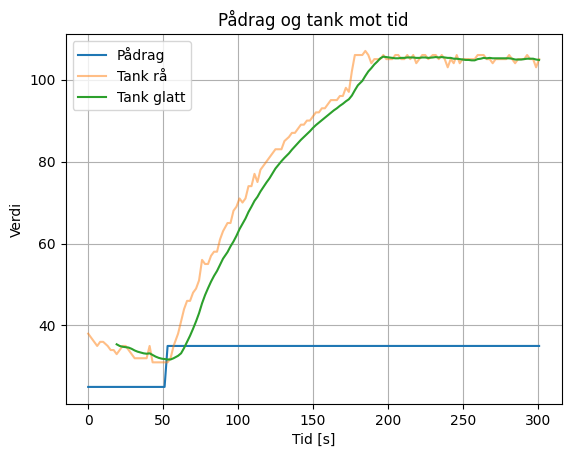

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(f"{CSV_FIL}")

df["Tidsstempel"] = pd.to_datetime(df["Tidsstempel"])

# Lag tid i sekunder fra start
df["tid_s"] = (df["Tidsstempel"] - df["Tidsstempel"].iloc[0]).dt.total_seconds()

# Glatting
df["tank_smooth"] = df["tank"].rolling(window=10).mean()

# Plot med sekunder i stedet for timestamp
plt.plot(df["tid_s"], df["pådrag"], label="Pådrag")
plt.plot(df["tid_s"], df["tank"], alpha=0.5, label="Tank rå")
plt.plot(df["tid_s"], df["tank_smooth"], label="Tank glatt")

plt.xlabel("Tid [s]")
plt.ylabel("Verdi")
plt.title("Pådrag og tank mot tid")
plt.legend()
plt.grid()

plt.savefig(f"{filnavn}.png")
plt.show()